In [1]:
import pandas as pd

In [2]:
#datacollection
dataset=pd.read_csv("insurance_pre.csv")
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [3]:
#datapreprocessing
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [4]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [5]:
#split input and output data
input_data=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
print(input_data)
output_data=dataset[['charges']]
print(output_data)

      age     bmi  children  sex_male  smoker_yes
0      19  27.900         0         0           1
1      18  33.770         1         1           0
2      28  33.000         3         1           0
3      33  22.705         0         1           0
4      32  28.880         0         1           0
...   ...     ...       ...       ...         ...
1333   50  30.970         3         1           0
1334   18  31.920         0         0           0
1335   18  36.850         0         0           0
1336   21  25.800         0         0           0
1337   61  29.070         0         0           1

[1338 rows x 5 columns]
          charges
0     16884.92400
1      1725.55230
2      4449.46200
3     21984.47061
4      3866.85520
...           ...
1333  10600.54830
1334   2205.98080
1335   1629.83350
1336   2007.94500
1337  29141.36030

[1338 rows x 1 columns]


In [6]:
#split train and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(input_data,output_data,test_size=0.30,random_state=0)
print(x_train)
print(y_train)
print(x_test)
print(y_test)

      age     bmi  children  sex_male  smoker_yes
1163   18  28.215         0         0           0
196    39  32.800         0         0           0
438    52  46.750         5         0           0
183    44  26.410         0         0           0
1298   33  27.455         2         1           0
...   ...     ...       ...       ...         ...
763    27  26.030         0         1           0
835    42  35.970         2         1           0
1216   40  25.080         0         1           0
559    19  35.530         0         1           0
684    33  18.500         1         0           0

[936 rows x 5 columns]
          charges
1163   2200.83085
196    5649.71500
438   12592.53450
183    7419.47790
1298   5261.46945
...           ...
763    3070.80870
835    7160.33030
1216   5415.66120
559    1646.42970
684    4766.02200

[936 rows x 1 columns]
      age     bmi  children  sex_male  smoker_yes
578    52  30.200         1         1           0
610    47  29.370         1         

In [26]:
#module creation
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='squared_error', splitter='random')
regressor=regressor.fit(x_train,y_train)

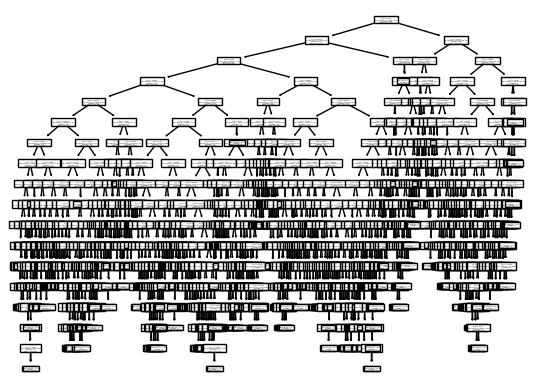

In [27]:
#to know the value of the atrributes in decision tree module 
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [28]:
y_predict=regressor.predict(x_test)
print(y_predict)
print(y_test)

[25992.82104   8930.93455  47269.854    12574.049     9264.797
 21984.47061   1615.7667   11299.343     7985.815     5209.57885
  6184.2994   10848.1343    7633.7206    4992.3764   35147.52848
 11299.343    12142.5786    3292.52985   6455.86265  33750.2918
 23306.547    12646.207     9625.92     23887.6627    1682.597
 11326.71487   3161.454     8538.28845   4134.08245   8027.968
  7640.3092   47269.854    12981.3457   20781.48892  20167.33603
  3554.203     8733.22925  39774.2763   39836.519     1880.07
  5266.3656    2866.091    37829.7242   43813.8661   36307.7983
  3579.8287   11299.343     6272.4772    4719.52405  12032.326
  2480.9791    4687.797    27218.43725  46661.4424   11856.4115
 19673.33573   3292.52985   8782.469    15828.82173  12913.9924
  1639.5631   47055.5321   14590.63205  25333.33284   9563.029
  9877.6077   33900.653    44585.45587   2585.269    15828.82173
 24513.09126  11763.0009   15518.18025  13887.204    13204.28565
 12629.8967    7526.70645  32108.66282  19

In [29]:
from sklearn.metrics  import r2_score
r_score=r2_score(y_test,y_predict)
print(r_score)

0.70780549131693


In [ ]:
#saving module
import pickle
filename="final_decisiontree_module.sav"
pickle.dump(regressor,open(filename,'wb'))

In [ ]:
loaded_module=pickle.load(open(filename,'rb'))
result=loaded_module.predict([[234,57654,3224,False,True]])
print(result)